In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Ready to build my first project")

Ready to build my first project


In [3]:
# Create a simulated lab QC dataset

np.random.seed(42)

n = 200

data = pd.DataFrame({
    "Date": pd.date_range(start="2026-01-01", periods=n, freq="D"),
    "Product_Lot": np.random.choice(["LOT-A", "LOT-B", "LOT-C"], n),
    "Test_Type": np.random.choice(["Endotoxin", "Bioburden"], n),
    "Result": np.round(np.random.normal(loc=0.045, scale=0.01, size=n), 3),
    "Specification_Limit": 0.050,
    "Analyst": np.random.choice(["Analyst 1", "Analyst 2", "Analyst 3"], n),
    "Instrument": np.random.choice(["Reader A", "Reader B"], n)
})

# Create Pass/Fail column
data["Status"] = np.where(data["Result"] <= data["Specification_Limit"], "Pass", "Fail")

# Show first 5 rows
data.head()

,Date,Product_Lot,Test_Type,Result,Specification_Limit,Analyst,Instrument,Status
0,2026-01-01,LOT-C,Bioburden,0.045,0.05,Analyst 1,Reader A,Pass
1,2026-01-02,LOT-A,Endotoxin,0.047,0.05,Analyst 1,Reader B,Pass
2,2026-01-03,LOT-C,Bioburden,0.051,0.05,Analyst 3,Reader A,Fail
3,2026-01-04,LOT-C,Endotoxin,0.042,0.05,Analyst 2,Reader A,Pass
4,2026-01-05,LOT-A,Bioburden,0.051,0.05,Analyst 3,Reader A,Fail


In [4]:
# Check dataset shape
data.shape

# Check data types
data.dtypes

# Summary statistics
data.describe()

,Date,Result,Specification_Limit
count,200,200.00000,2.000000e+02
mean,2026-04-10 12:00:00,0.04434,5.000000e-02
min,2026-01-01 00:00:00,0.01900,5.000000e-02
25%,2026-02-19 18:00:00,0.03800,5.000000e-02
50%,2026-04-10 12:00:00,0.04400,5.000000e-02
75%,2026-05-30 06:00:00,0.05000,5.000000e-02
max,2026-07-19 00:00:00,0.07800,5.000000e-02
std,NaN,0.00993,3.478153e-17


In [5]:
# Count Pass vs Fail
data["Status"].value_counts()

,count
Status,
Pass,152
Fail,48


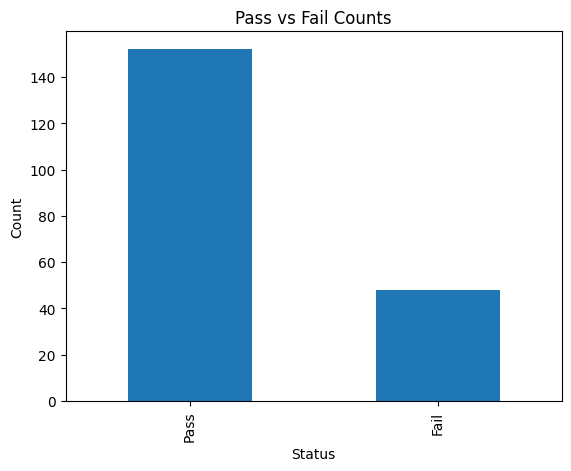

In [6]:
# Plot Pass vs Fail
data["Status"].value_counts().plot(kind="bar")
plt.title("Pass vs Fail Counts")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

In [7]:
# Filter Fail (OOS results)
oos_data = data[data["Status"] == "Fail"]

oos_data.head()

,Date,Product_Lot,Test_Type,Result,Specification_Limit,Analyst,Instrument,Status
2,2026-01-03,LOT-C,Bioburden,0.051,0.05,Analyst 3,Reader A,Fail
4,2026-01-05,LOT-A,Bioburden,0.051,0.05,Analyst 3,Reader A,Fail
14,2026-01-15,LOT-B,Bioburden,0.056,0.05,Analyst 1,Reader A,Fail
16,2026-01-17,LOT-B,Endotoxin,0.051,0.05,Analyst 2,Reader B,Fail
23,2026-01-24,LOT-B,Endotoxin,0.063,0.05,Analyst 2,Reader A,Fail


In [8]:
# Failures by Analyst
oos_data["Analyst"].value_counts()

,count
Analyst,
Analyst 3,17
Analyst 2,17
Analyst 1,14


In [9]:
# Failures by Instrument
oos_data["Instrument"].value_counts()

,count
Instrument,
Reader A,27
Reader B,21


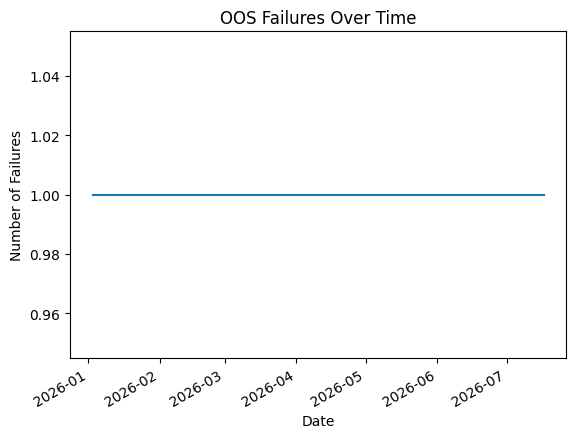

In [10]:
# Convert Date to datetime (just to be safe)
data["Date"] = pd.to_datetime(data["Date"])

# Group by date and count failures
fail_trend = oos_data.groupby("Date").size()

# Plot
plt.figure()
fail_trend.plot()
plt.title("OOS Failures Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Failures")
plt.show()

In [13]:
# compare average results by test type
data.groupby("Test_Type")["Result"].mean()

,Result
Test_Type,
Bioburden,0.043796
Endotoxin,0.044978



Laboratory QC Data Analysis (Beginner Project)

Objective:
I wanted to analyze lab QC data to understand pass/fail results and see if there are any patterns.

What I did:

* Created a dataset with 200 lab test results
* Set a specification limit (0.05)
* Classified results as Pass or Fail
* Counted how many tests passed and failed
* Plotted results to see trends over time
* Average results for Endotoxin were slightly higher than Bioburden, but both remained below the specification limit.


What I found:


* Most tests passed (~76%)
* Some tests failed (~24%)
* Failures happened across different dates
* No clear trend of increasing failures


Conclusion:

The process seems mostly stable, but failures still ocuur and should be monitored.

Tools used: Python (pandas, NumPy, matplotlib)









